# SAM 3 Agent

This notebook shows an example of how an MLLM can use SAM 3 as a tool, i.e., "SAM 3 Agent", to segment more complex text queries such as "the leftmost child wearing blue vest".

## Env Setup

First install `sam3` in your environment using the [installation instructions](https://github.com/facebookresearch/sam3?tab=readme-ov-file#installation) in the repository.

In [2]:
import torch
# turn on tfloat32 for Ampere GPUs
# https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# use bfloat16 for the entire notebook. If your card doesn't support it, try float16 instead
torch.autocast("mps", dtype=torch.bfloat16).__enter__()

# inference mode for the whole notebook. Disable if you need gradients
torch.inference_mode().__enter__()

In [3]:
import os
import platform

SAM3_ROOT = os.path.dirname(os.getcwd())
os.chdir(SAM3_ROOT)

# # If running on MacOS, set device to 'mps', otherwise fall back to 'cuda'
# if platform.system() == "Darwin":
#     DEVICE = "mps"
#     print("Using MPS (Metal Performance Shaders) on macOS.")
# else:
#     DEVICE = "cuda"
#     os.environ["CUDA_VISIBLE_DEVICES"] = "0"
#     _ = os.system("nvidia-smi")
#     print("Using CUDA on non-macOS system.")

DEVICE = "mps"

# You can later use DEVICE variable to move tensors/models to the right device if needed

## Build SAM3 Model

In [4]:
import sam3
from sam3 import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor

sam3_root = os.path.dirname(sam3.__file__)
bpe_path = f"{sam3_root}/assets/bpe_simple_vocab_16e6.txt.gz"
model = build_sam3_image_model(bpe_path=bpe_path, device='mps')
processor = Sam3Processor(model, confidence_threshold=0.5, device='mps')

/Users/marcolomele/Documents/Repos/sam3/sam3/model_builder.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/Users/marcolomele/Documents/Repos/sam3/sam3/model/sam3_video_inference.py:801: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.bfloat16)
/Users/marcolomele/Documents/Repos/sam3/sam3/model/sam3_video_inference.py:909: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.bfloat16)


## LLM Setup

Config which MLLM to use, it can either be a model served by vLLM that you launch from your own machine or a model is served via external API. If you want to using a vLLM model, we also provided insturctions below.

In [25]:
import base64

# Load env.env from repo root (OLLAMA_API_KEY, etc.)
_env_path = os.path.join(os.getcwd(), "env.env")
if os.path.isfile(_env_path):
    with open(_env_path) as _f:
        for _line in _f:
            _line = _line.strip()
            if _line and not _line.startswith("#") and "=" in _line:
                _k, _v = _line.split("=", 1)
                os.environ[_k.strip()] = _v.strip().strip('"').strip("'")

def _get_api_keys(cfg, key, default):
    """Resolve API keys from config or env (e.g. for Ollama Cloud)."""
    val = cfg.get(key, os.environ.get("OLLAMA_API_KEY", default))
    return [val] if val else []


def init_vlm(cfg):
    """Initialize Ollama client for use as VLM (local or cloud)."""
    keys = _get_api_keys(cfg, "api_key", "ollama")
    host = cfg.get("host", "http://localhost:11434")
    headers = {"Authorization": f"Bearer {keys[0]}"} if keys and keys[0] else None
    from ollama import Client
    return {
        "keys": keys,
        "idx": 0,
        "client": Client(host=host, headers=headers),
    }


def vlm_caption(vlm_state, model, images_b64, prompt, system_prompt=None):
    """Get caption from Ollama given prompt and optional images (base64). Optionally pass system prompt (repo MLLM instructions)."""
    from ollama import ResponseError
    msgs = []
    if system_prompt:
        msgs.append({"role": "system", "content": system_prompt})
    msgs.append({"role": "user", "content": prompt, "images": images_b64 or []})
    text = ""
    try:
        for part in vlm_state["client"].chat(
            model=model, messages=msgs, stream=True,
            options={"temperature": 0, "seed": 777, "num_predict": 2048},
        ):
            text += part.message.content or ""
    except ResponseError as e:
        if getattr(e, "status_code", None) == 404:
            raise RuntimeError(
                f"Ollama model '{model}' not found. For local Ollama run: ollama pull {model}"
            ) from e
        raise
    return text.strip()


def _image_path_to_b64(image_path):
    ext = os.path.splitext(image_path)[1].lower()
    mime = {".jpg": "image/jpeg", ".jpeg": "image/jpeg", ".png": "image/png", ".gif": "image/gif", ".webp": "image/webp"}.get(ext, "image/jpeg")
    with open(image_path.replace("?", "%3F"), "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")


def _messages_to_ollama_user_content(messages):
    """Convert agent messages to (system_prompt, user_prompt, images_b64) for Ollama. Includes the repo system prompt so the MLLM receives the same instructions as with vLLM/OpenAI."""
    system_prompt = None
    parts = []
    images_b64 = []
    for msg in messages:
        if msg.get("role") == "system" and "content" in msg:
            content = msg["content"]
            if isinstance(content, str):
                system_prompt = content.strip() or None
            elif isinstance(content, list):
                for c in content:
                    if isinstance(c, dict) and c.get("type") == "text":
                        system_prompt = (c.get("text") or "").strip() or None
                        break
            # do not break: continue to process user messages for prompt and images
        if msg.get("role") != "user" or "content" not in msg:
            continue
        for c in msg["content"]:
            if isinstance(c, dict):
                if c.get("type") == "text":
                    parts.append(c.get("text", ""))
                elif c.get("type") == "image" and "image" in c:
                    try:
                        images_b64.append(_image_path_to_b64(c["image"]))
                    except Exception as e:
                        print(f"Warning: could not load image {c['image']}: {e}")
    prompt = "\n\n".join(p for p in parts if p).strip() or "(no text)"
    return system_prompt, prompt, images_b64


def make_ollama_send_request(vlm_state, model_name):
    """Return a send_generate_request(messages) that uses Ollama via vlm_caption."""
    def send_generate_request(messages):
        system_prompt, prompt, images_b64 = _messages_to_ollama_user_content(messages)
        return vlm_caption(vlm_state, model_name, images_b64, prompt, system_prompt=system_prompt)
    return send_generate_request

In [26]:
# --- LLM config: choose vLLM or Ollama (local / cloud) ---
LLM_CONFIGS = {
    "qwen3_vl_8b_thinking": {
        "provider": "vllm",
        "model": "Qwen/Qwen3-VL-8B-Thinking",
    },
    "ollama_local": {
        "provider": "ollama",
        "model": "qwen3-vl:235b-cloud",  # or "qwen2.5-vl", "llama3.2-vision", etc. Run: ollama pull llava
        "host": "http://localhost:11434",
    },
    "ollama_cloud": {
        "provider": "ollama",
        "model": "qwen3-vl:235b-cloud",
        "host": "https://ollama.com",
        "api_key": os.environ.get("OLLAMA_API_KEY", ""),
    },
}

model = "ollama_cloud" 
LLM_API_KEY = os.environ.get("LLM_API_KEY", "DUMMY_API_KEY")

llm_config = LLM_CONFIGS[model].copy()
llm_config["api_key"] = llm_config.get("api_key") or LLM_API_KEY
llm_config["name"] = model

if llm_config["provider"] == "ollama":
    vlm_state = init_vlm(llm_config)
    send_generate_request = make_ollama_send_request(vlm_state, llm_config["model"])
    LLM_SERVER_URL = None 
else:
    vlm_state = None
    if llm_config["provider"] == "vllm":
        LLM_SERVER_URL = "http://0.0.0.0:8001/v1"  # replace with your vLLM server address if needed
    else:
        LLM_SERVER_URL = llm_config.get("base_url")

## Run SAM3 Agent Inference

In [9]:
from functools import partial
from IPython.display import display, Image
from sam3.agent.client_llm import send_generate_request as send_generate_request_orig
from sam3.agent.client_sam3 import call_sam_service as call_sam_service_orig
from sam3.agent.inference import run_single_image_inference

------------------------------ Starting SAM 3 Agent Session... ------------------------------ 
> Text prompt: the leftmost child wearing blue vest
> Image path: /Users/marcolomele/Documents/Repos/sam3/assets/images/test_image.jpg



------------------------------ Round 1------------------------------




>>> MLLM Response [start]
<tool> {"name": "segment_phrase", "parameters": {"text_prompt": "child"}} </tool>
<<< MLLM Response [end]

🔍 Calling segment_phrase tool...
📞 Loading image '/Users/marcolomele/Documents/Repos/sam3/assets/images/test_image.jpg' and sending with prompt 'child'...
✅ Raw JSON response saved to 'agent_output/sam_out/Users-marcolomele-Documents-Repos-sam3-assets-images-test_image.jpg/child.json'
🔍 Rendering visualizations on the image ...
✅ Saved visualization at: agent_output/sam_out/Users-marcolomele-Documents-Repos-sam3-assets-images-test_image.jpg/child.png


>>> sam3_output_text_message:
 The segment_phrase tool generated 6 available masks. All 6 available mask

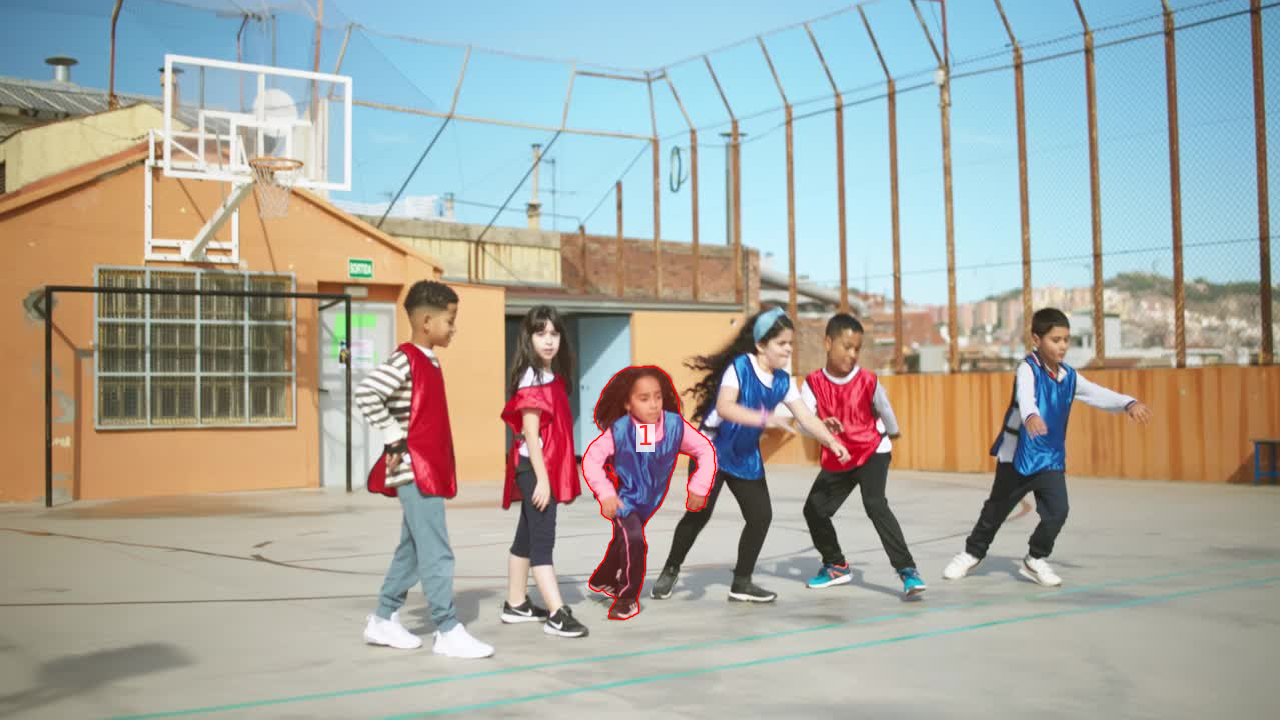

In [11]:
# prepare input args and run single image inference
image = "assets/images/test_image.jpg"
prompt = "the leftmost child wearing blue vest"
image = os.path.abspath(image)
# Use OpenAI-compatible client only when not using Ollama (Ollama path set in LLM Setup cell)
if llm_config["provider"] != "ollama":
    send_generate_request = partial(send_generate_request_orig, server_url=LLM_SERVER_URL, model=llm_config["model"], api_key=llm_config["api_key"])
call_sam_service = partial(call_sam_service_orig, sam3_processor=processor)
output_image_path = run_single_image_inference(
    image, prompt, llm_config, send_generate_request, call_sam_service,
    debug=True, output_dir="agent_output"
)

# display output
if output_image_path is not None:
    display(Image(filename=output_image_path))

# VLM + SAM3

## Img Paths

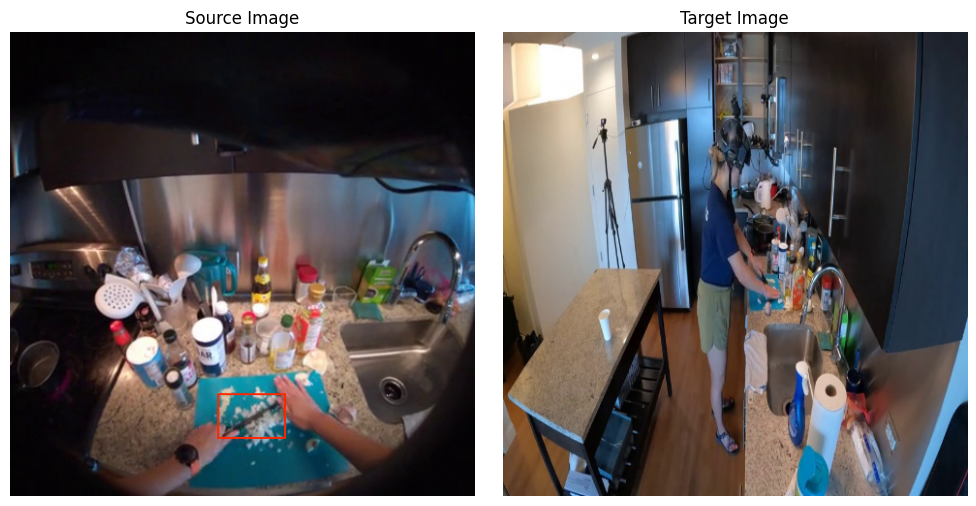

In [58]:
import matplotlib.pyplot as plt
from PIL import Image

source_img = "../reluminati-research/local_misc/LMEEC-failure-cases/egoexo-clean/iou0_cooking_small_8acb2112_f7950_cross_box.png"
target_img = "../reluminati-research/local_misc/LMEEC-failure-cases/egoexo-clean/iou0_cooking_small_8acb2112_f7950.png"

# Load images
img1 = Image.open(source_img)
img2 = Image.open(target_img)

# Visualise side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img1)
axes[0].set_title("Source Image")
axes[0].axis('off')

axes[1].imshow(img2)
axes[1].set_title("Target Image")
axes[1].axis('off')

plt.tight_layout()
plt.show()

## VLM output (manual)

In [59]:
vlm_output = " silver knife, on the blue cutting board among chopped food pieces"

## SAM3 call

------------------------------ Starting SAM 3 Agent Session... ------------------------------ 
> Text prompt:  silver knife, on the blue cutting board among chopped food pieces
> Image path: /Users/marcolomele/Documents/Repos/reluminati-research/local_misc/LMEEC-failure-cases/egoexo-clean/iou0_cooking_small_8acb2112_f7950.png



------------------------------ Round 1------------------------------




>>> MLLM Response [start]
<tool> {"name": "segment_phrase", "parameters": {"text_prompt": "silver knife"}} </tool>
<<< MLLM Response [end]

🔍 Calling segment_phrase tool...
📞 Loading image '/Users/marcolomele/Documents/Repos/reluminati-research/local_misc/LMEEC-failure-cases/egoexo-clean/iou0_cooking_small_8acb2112_f7950.png' and sending with prompt 'silver knife'...
✅ Raw JSON response saved to 'agent_output/sam_out/Users-marcolomele-Documents-Repos-reluminati-research-local_misc-LMEEC-failure-cases-egoexo-clean-iou0_cooking_small_8acb2112_f7950.png/silver knife.json'
🔍 Rendering visualiz

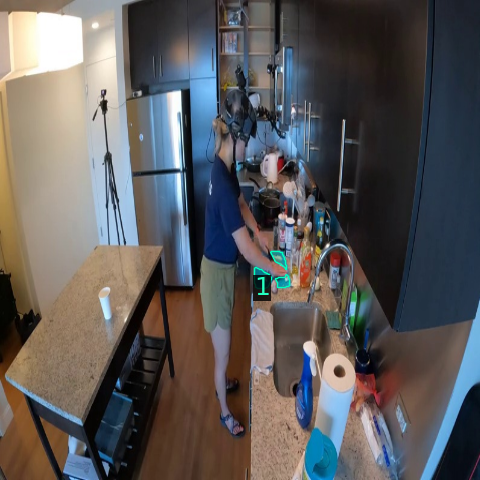

In [60]:
from IPython.display import display, Image

image = target_img
prompt = vlm_output
image = os.path.abspath(image)
# Use OpenAI-compatible client only when not using Ollama (Ollama path set in LLM Setup cell)
if llm_config["provider"] != "ollama":
    send_generate_request = partial(send_generate_request_orig, server_url=LLM_SERVER_URL, model=llm_config["model"], api_key=llm_config["api_key"])
call_sam_service = partial(call_sam_service_orig, sam3_processor=processor)
output_image_path = run_single_image_inference(
    image, prompt, llm_config, send_generate_request, call_sam_service,
    debug=True, output_dir="agent_output"
)

# display output
if output_image_path is not None:
    display(Image(filename=output_image_path))